# Rapport Jupyter Notebook - Inved Corp

Noé Berdoz
Cyrille Dos Ghali
Steeve Leuba

_26_HES-SO-ARC_64-61.1 Science des données_


## Chapitre 1 — Compréhension métier

> **Méthodologie.** Nous suivons la démarche **CRISP-ML(Q)**, extension de CRISP-DM qui ajoute une exigence explicite de qualité à chaque phase, pertinente au vu de nos engagements de monitoring en production (cf. Phase 7, surveillance et maintenance).

### 1.1 Le contexte : Inved Corp
**Inved Corp** est une société de conseil en immobilier spécialisée dans l'évaluation et la vente de biens résidentiels. L'évaluation du prix d'une maison se fait en analysant 79 paramètres distincts. Actuellement, nos consultants passent en moyenne 4 heures pour évaluer manuellement une seule propriété. Ce processus est non seulement chronophage, mais une mauvaise estimation peut également faire stagner un bien sur le marché pendant de nombreux mois.

### 1.2 La solution IA
Pour moderniser notre approche et gagner en efficacité, nous avons décidé de développer un modèle de **Machine Learning supervisé**. Ce modèle sera capable de prédire le prix de vente final d'un bien immobilier.

### 1.3 Comment le modèle sera-t-il utilisé ?
L'IA développée sera un **outil d'assistance** interactif et non un processus 100 % autonome. Les experts d'Inved Corp interagiront avec le modèle via une interface web interne qui leur fournira instantanément trois informations clés pour leur évaluation :
1. Le prix de vente prédit.
2. Un intervalle de confiance.
3. Les 3 caractéristiques (features) ayant eu le plus grand impact sur cette prédiction.

À partir de là, le modèle ouvre la porte à deux stratégies métiers :
* **Conseil en rénovation :** Si le prix prédit par l'IA est nettement inférieur aux attentes du client, le consultant s'appuiera sur l'importance des variables (*Feature Importances*) pour recommander des rénovations ciblées (par exemple, la qualité de la cuisine, `KitchenQual`) afin de faire monter la valeur du bien.
* **Label de confiance :** Si le prix proposé est cohérent avec le marché, le bien sera publié avec le label commercial **"Price certified by Inved AI"**, renforçant ainsi la confiance des futurs acheteurs.

### 1.4 Objectifs et KPIs (Indicateurs de Performance)
Le succès de ce projet IA sera mesuré en continu à l'aide d'indicateurs de performance (KPIs) clairs :
* **Gain de temps :** Réduire de 50 % le temps passé par un consultant sur une évaluation (passant de 4 heures à 2 heures) dès le premier trimestre de déploiement.
* **Taux de conversion :** Augmenter de 20 % le pourcentage de propriétés vendues avec succès dans les 90 jours au cours de la prochaine année. La justesse des prix de l'IA évitera que les biens ne stagnent sur le marché.
* **Taux de correction manuelle :** L'objectif est que les consultants ne modifient manuellement les prédictions de l'IA que dans moins de 10 % des cas durant la première année, prouvant ainsi que l'outil est fiable et adopté par les experts.

### 1.5 Évaluation du modèle : Le choix du RMSLE
Afin de suivre la précision des algorithmes (Accuracy Tracking), nous utiliserons l'erreur quadratique moyenne sur le logarithme des prix, soit la métrique **RMSLE** (*Root Mean Squared Logarithmic Error*).

$$\text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\Big(\ln(1+\hat{y}_i) - \ln(1+y_i)\Big)^2}$$

où $n$ est le nombre de biens évalués, $\hat{y}_i$ le prix prédit et $y_i$ le prix réel du bien $i$.

**Pourquoi le RMSLE ?**
Une erreur de 10 000 n'as pas le même poids sur un studio à 100 000 que sur une villa à 1 000 000. Le RMSLE, grâce au logarithme, permet de contrer cette injustice en calculant une erreur relative. RMSLE donne en résultat un pourcentage. Une erreur de 10% sera pénalisée de la même manière pour une petite maison ou une propriété de luxe. Le modèle est donc équitable pour tous les clients.

**L'avantage métier du RMSLE :**
Le RMSLE présente en outre une asymétrie utile **en dollars** : à écart relatif égal, une sous-estimation est pénalisée un peu plus lourdement qu'une sur-estimation (la fonction log est convexe). C'est un comportement cohérent avec le métier, sous-évaluer un bien fait perdre de l'argent au vendeur et entame sa confiance en Inved Corp. En **espace log**, là où le modèle est entraîné, la pénalité reste néanmoins symétrique : la gestion fine de l'asymétrie métier (sur-estimation vs sous-estimation) est donc déléguée à la validation finale du consultant et au suivi métier en production (cf. Phases 5 et 7).

---

Maintenant que notre problématique métier et nos objectifs sont fixés, la prochaine étape consiste à comprendre les données à notre disposition pour construire ce modèle. C'est l'objectif de l'étape suivante : l'Analyse Exploratoire des Données (EDA).

## Chapitre 2 — Analyse exploratoire des données

### 2.1. Vue d’ensemble du jeu de données

Nous commençons par un audit global du jeu d'entraînement afin de comprendre sa structure : dimensions, types de variables, premières observations et rôle de la variable cible `SalePrice`. Cette étape permet de vérifier que les données sont bien chargées et de préparer la suite de l’analyse exploratoire.

In [1]:
# Chargement des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('./data/train.csv', sep=',')

pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid")

print("Dimensions du dataset :", df.shape)
display(df.head())
df.info()
display(df.describe().T)

print("\nVariable cible :", 'SalePrice')
print(df['SalePrice'].describe())

Dimensions du dataset : (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



Variable cible : SalePrice
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


### 2.2. Typologie des variables

Le jeu de données contient des variables numériques, catégorielles et ordinales. Avant d’analyser les relations avec le prix, il est nécessaire de distinguer ces groupes pour adapter les visualisations et les traitements.

In [2]:
# Séparation simple entre variables numériques et catégorielles
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Nombre de variables numériques : {len(num_cols)}")
print(f"Nombre de variables catégorielles : {len(cat_cols)}")

print("\nExemples de variables numériques :")
print(num_cols[:15])

print("\nExemples de variables catégorielles :")
print(cat_cols[:15])

# Tableau récapitulatif
var_types = pd.DataFrame({
    'variable': df.columns,
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum().values,
    'missing_pct': (df.isna().mean() * 100).round(2).values
})

display(var_types.sort_values(by=['missing_pct', 'dtype'], ascending=[False, True]))

Nombre de variables numériques : 38
Nombre de variables catégorielles : 43

Exemples de variables numériques :
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF']

Exemples de variables catégorielles :
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl']


,variable,dtype,missing_values,missing_pct
PoolQC,PoolQC,object,1453,99.52
MiscFeature,MiscFeature,object,1406,96.30
Alley,Alley,object,1369,93.77
Fence,Fence,object,1179,80.75
MasVnrType,MasVnrType,object,872,59.73
...,...,...,...,...
KitchenQual,KitchenQual,object,0,0.00
Functional,Functional,object,0,0.00
PavedDrive,PavedDrive,object,0,0.00
SaleType,SaleType,object,0,0.00


### 2.3. Compréhension métier des variables

La documentation du dataset montre que les variables décrivent plusieurs dimensions d’un bien immobilier : qualité globale, surface habitable, quartier, année de construction, sous-sol, garage, équipements extérieurs et contexte de vente. Il est important de comprendre les données afin d'interpréter correctement les distributions, les valeurs manquantes et les relations avec `SalePrice`.

In [3]:
# Organisation simple des variables par thème
feature_groups = {
    "Identification": ['Id', 'MSSubClass', 'MSZoning'],
    "Terrain et localisation": ['LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Neighborhood'],
    "Qualité et état": ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'KitchenQual'],
    "Temporalité": ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 'MoSold'],
    "Surfaces habitables": ['1stFlrSF', '2ndFlrSF', 'GrLivArea', 'TotalBsmtSF'],
    "Sous-sol": ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'],
    "Garage": ['GarageType', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond'],
    "Extérieur et équipements": ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'PoolArea', 'Fence'],
    "Vente": ['SaleType', 'SaleCondition', 'SalePrice']
}

for group_name, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in df.columns]
    print(f"\n{group_name} ({len(existing_cols)} variables) :")
    print(existing_cols)


Identification (3 variables) :
['Id', 'MSSubClass', 'MSZoning']

Terrain et localisation (6 variables) :
['LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Neighborhood']

Qualité et état (5 variables) :
['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'KitchenQual']

Temporalité (5 variables) :
['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 'MoSold']

Surfaces habitables (4 variables) :
['1stFlrSF', '2ndFlrSF', 'GrLivArea', 'TotalBsmtSF']

Sous-sol (6 variables) :
['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']

Garage (6 variables) :
['GarageType', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond']

Extérieur et équipements (5 variables) :
['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'PoolArea', 'Fence']

Vente (3 variables) :
['SaleType', 'SaleCondition', 'SalePrice']


### 2.4. Analyse de la variable cible

Avant d’étudier les variables explicatives, il est essentiel d’analyser la variable cible `SalePrice`. Nous cherchons ici à comprendre son niveau global, sa dispersion, sa forme de distribution et la présence éventuelle de valeurs extrêmes. Cette étape permet aussi d’évaluer si une transformation logarithmique est pertinente.

In [4]:
# Statistiques descriptives de la cible
saleprice_stats = df['SalePrice'].describe().to_frame().T
saleprice_stats['skew'] = df['SalePrice'].skew()
saleprice_stats['kurtosis'] = df['SalePrice'].kurt()

display(saleprice_stats)

print(f"Asymétrie (skewness) : {df['SalePrice'].skew():.3f}")
print(f"Kurtosis : {df['SalePrice'].kurt():.3f}")

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0,1.882876,6.536282


Asymétrie (skewness) : 1.883
Kurtosis : 6.536


#### 2.4.1 Distribution brute de `SalePrice`

Nous visualisons la distribution des prix de vente afin d’identifier sa forme générale, sa dispersion et d’éventuelles valeurs extrêmes. L’objectif est de vérifier si la variable cible suit une distribution équilibrée ou si elle présente une forte asymétrie.

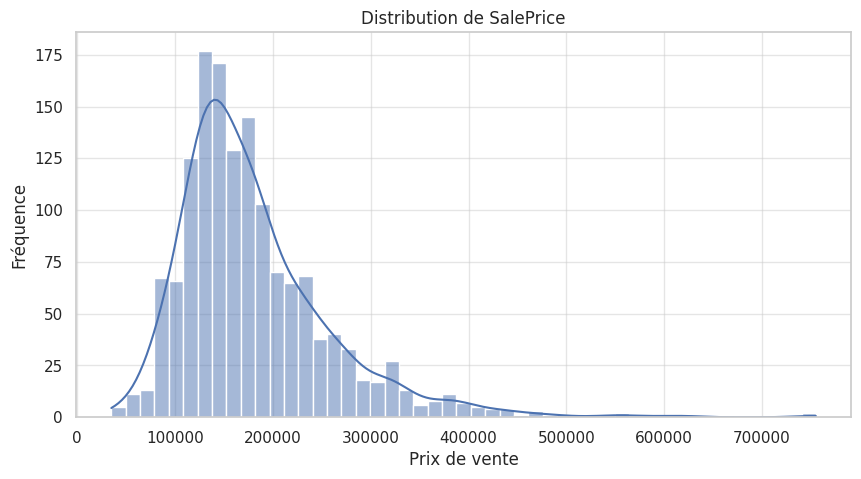

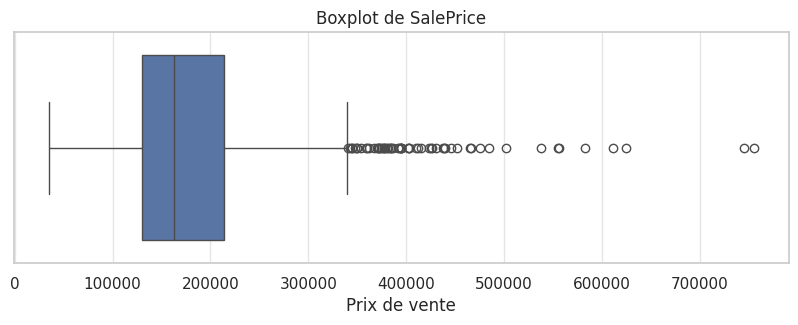

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, ax=ax)
ax.set_title("Distribution de SalePrice")
ax.set_xlabel("Prix de vente")
ax.set_ylabel("Fréquence")
plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=df['SalePrice'], ax=ax)
ax.set_title("Boxplot de SalePrice")
ax.set_xlabel("Prix de vente")
plt.show()

#### 2.4.2 Effet d’une transformation logarithmique

Une transformation logarithmique est souvent utilisée lorsque la variable cible est fortement asymétrique. Nous comparons ici la distribution brute de `SalePrice` avec celle de `log(SalePrice)` afin de vérifier si cette transformation rend la distribution plus régulière.

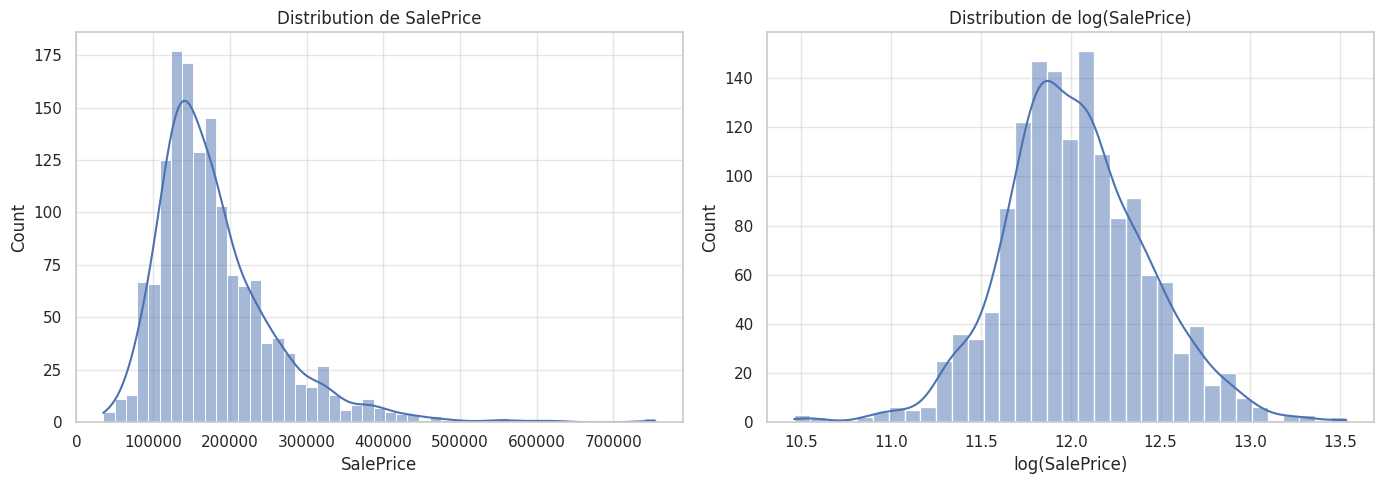

Skewness de SalePrice      : 1.883
Skewness de log(SalePrice) : 0.121


In [6]:
# Transformation logarithmique
df['SalePrice_log'] = np.log(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("Distribution de SalePrice")
axes[0].set_xlabel("SalePrice")

sns.histplot(df['SalePrice_log'], kde=True, ax=axes[1])
axes[1].set_title("Distribution de log(SalePrice)")
axes[1].set_xlabel("log(SalePrice)")

plt.tight_layout()
plt.show()

print(f"Skewness de SalePrice      : {df['SalePrice'].skew():.3f}")
print(f"Skewness de log(SalePrice) : {df['SalePrice_log'].skew():.3f}")

**Test statistique de normalité (Shapiro-Wilk).** Le visuel suggère que la transformation logarithmique rapproche la cible d'une loi normale. Confirmons-le par un test de **Shapiro-Wilk** (H0 : la distribution est normale ; p < 0,05 ⇒ on rejette la normalité).

In [7]:
# Shapiro-Wilk : cible brute vs log-transformée (n=1460 < 5000, test fiable)
w_raw, p_raw = stats.shapiro(df['SalePrice'])
w_log, p_log = stats.shapiro(df['SalePrice_log'])
print(f"SalePrice brut  : W = {w_raw:.4f}   p = {p_raw:.2e}")
print(f"log(SalePrice)  : W = {w_log:.4f}   p = {p_log:.2e}")

SalePrice brut  : W = 0.8697   p = 3.21e-33
log(SalePrice)  : W = 0.9912   p = 1.15e-07


**Ce que montre le test.** Sur `SalePrice` brut, la p-value est quasi nulle → on rejette nettement la normalité (forte asymétrie à droite). Après `log`, la statistique W se rapproche de 1 et la p-value augmente de plusieurs ordres de grandeur : la distribution devient **bien plus proche de la normale** (sans être parfaite). C'est la justification *statistique*, au-delà du visuel, de modéliser la cible log-transformée et d'évaluer en **RMSLE** (erreur relative).

#### 2.4.3 Lecture de la distribution par quantiles

Les quantiles permettent de mieux situer les niveaux de prix dans le jeu de données. Ils offrent une lecture plus robuste que la moyenne seule et facilitent l’interprétation des segments de marché.

In [8]:
quantiles = df['SalePrice'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame(name='SalePrice')
display(quantiles)

,SalePrice
0.01,61815.97
0.05,88000.00
0.25,129975.00
0.50,163000.00
0.75,214000.00
0.95,326100.00
0.99,442567.01


#### 2.4.4 Synthèse sur la cible

L’analyse de `SalePrice` montre que la variable cible présente une dispersion importante et une asymétrie marquée vers les grandes valeurs. La transformation logarithmique permet de rendre la distribution plus régulière, ce qui justifie son utilisation dans les étapes de modélisation. Les valeurs extrêmes observées seront étudiées plus en détail lors de l’analyse bivariée et du traitement des outliers.

### 2.5 Analyse des valeurs manquantes

Avant toute préparation des données, il est nécessaire d’identifier les variables contenant des valeurs manquantes. Dans ce jeu de données, certains `NaN` correspondent à de véritables absences d’information, tandis que d’autres traduisent simplement l’absence d’un équipement, comme un garage, une piscine ou un sous-sol.

In [9]:
# Nombre et pourcentage de valeurs manquantes par variable
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)

# On conserve uniquement les variables avec au moins une valeur manquante
missing_df = missing_df[missing_df['missing_count'] > 0]

display(missing_df)
print(f"Nombre de variables avec valeurs manquantes : {missing_df.shape[0]}")

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


Nombre de variables avec valeurs manquantes : 19


#### 2.5.1 Variables les plus concernées par les valeurs manquantes

Nous représentons les variables les plus touchées par les valeurs manquantes afin d’identifier celles qui nécessiteront une attention particulière lors du prétraitement.

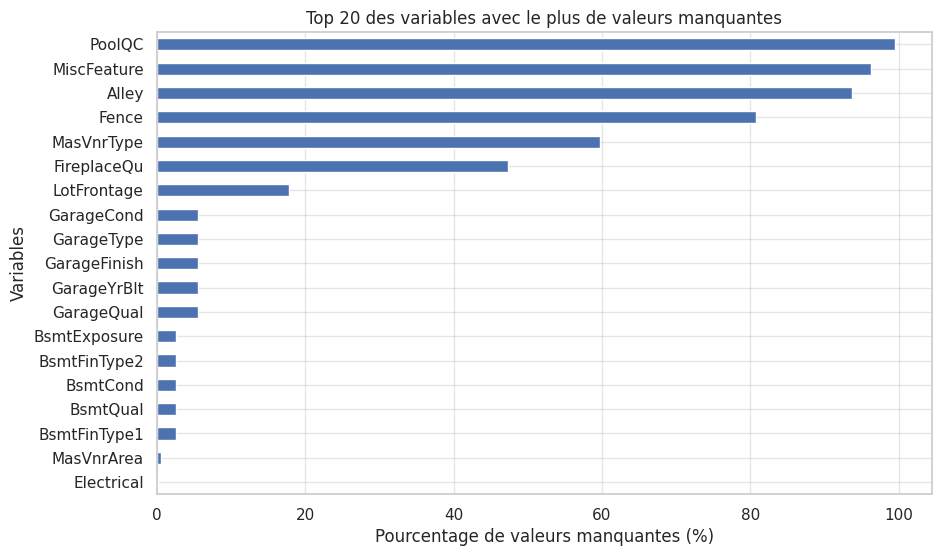

In [10]:
plt.figure(figsize=(10, 6))
missing_df.head(20)['missing_pct'].sort_values().plot(kind='barh')
plt.title("Top 20 des variables avec le plus de valeurs manquantes")
plt.xlabel("Pourcentage de valeurs manquantes (%)")
plt.ylabel("Variables")
plt.show()

#### 2.5.2 Valeurs manquantes et absence d’équipement

Dans le dataset, plusieurs valeurs manquantes ont une signification métier claire : elles indiquent non pas une donnée oubliée, mais l’absence d’un élément sur le bien immobilier. Il est donc important de distinguer ces cas des véritables données manquantes avant de choisir une stratégie d’imputation.

In [11]:
# Variables pour lesquelles NaN signifie généralement absence d'équipement
na_means_none = [
    'Alley',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

na_none_summary = pd.DataFrame({
    'missing_count': df[na_means_none].isnull().sum(),
    'missing_pct': (df[na_means_none].isnull().mean() * 100).round(2)
}).sort_values(by='missing_pct', ascending=False)

display(na_none_summary)


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
GarageType,81,5.55
GarageCond,81,5.55
GarageFinish,81,5.55
GarageQual,81,5.55
GarageYrBlt,81,5.55


#### 2.5.3 Valeurs manquantes à examiner plus attentivement

Toutes les valeurs manquantes ne correspondent pas à une absence d’équipement. Certaines variables demandent une analyse plus prudente, car leurs `NaN` peuvent refléter une information réellement absente ou incomplète.

In [12]:
# Variables avec valeurs manquantes hors cas "absence d'équipement"
potentially_problematic_na = [col for col in missing_df.index if col not in na_means_none]

problematic_na_df = pd.DataFrame({
    'missing_count': df[potentially_problematic_na].isnull().sum(),
    'missing_pct': (df[potentially_problematic_na].isnull().mean() * 100).round(2),
    'dtype': df[potentially_problematic_na].dtypes.astype(str)
}).sort_values(by='missing_pct', ascending=False)

display(problematic_na_df)

,missing_count,missing_pct,dtype
MasVnrType,872,59.73,object
LotFrontage,259,17.74,float64
MasVnrArea,8,0.55,float64
Electrical,1,0.07,object


#### 2.5.4 Synthèse sur les valeurs manquantes

L’analyse des valeurs manquantes met en évidence deux situations distinctes : d’une part, des absences d’équipement explicitement codées par des `NaN`, et d’autre part, quelques variables nécessitant une imputation plus prudente. Cette étape est essentielle pour éviter des traitements incorrects et préparer un prétraitement cohérent avec la signification des données.

### 2.6. Analyse univariée des variables

L’analyse univariée consiste à étudier chaque variable séparément. Nous commençons par les variables numériques afin d’examiner leur distribution, leur dispersion et la présence éventuelle de valeurs extrêmes.

In [13]:
# Variables numériques (hors identifiant et cible/log-cible)
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features = [col for col in num_features if col not in ['Id', 'SalePrice', 'SalePrice_log']]

print(f"Nombre de variables numériques analysées : {len(num_features)}")
print(num_features)

Nombre de variables numériques analysées : 36
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


#### 2.6.1 Statistiques descriptives

Nous calculons les statistiques descriptives des variables numériques pour obtenir une première lecture de leur niveau, de leur dispersion et de leur amplitude.

In [14]:
num_summary = df[num_features].describe().T
num_summary['median'] = df[num_features].median()
num_summary['skew'] = df[num_features].skew()
num_summary['kurtosis'] = df[num_features].kurt()

display(num_summary.sort_values(by='std', ascending=False))

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0,9478.5,12.207688,203.243271
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0,1464.0,1.366560,4.895121
MiscVal,1460.0,43.489041,496.123024,0.0,0.00,0.0,0.00,15500.0,0.0,24.476794,701.003342
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0,383.5,1.685503,11.118236
BsmtUnfSF,1460.0,567.240411,441.866955,0.0,223.00,477.5,808.00,2336.0,477.5,0.920268,0.474994
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0,991.5,1.524255,13.250483
2ndFlrSF,1460.0,346.992466,436.528436,0.0,0.00,0.0,728.00,2065.0,0.0,0.813030,-0.553464
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0,1087.0,1.376757,5.745841
GarageArea,1460.0,472.980137,213.804841,0.0,334.50,480.0,576.00,1418.0,480.0,0.179981,0.917067
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0,0.0,2.669084,10.082417


#### 2.6.2 Distribution de quelques variables numériques clés

Nous visualisons plusieurs variables numériques importantes afin d’observer leur forme de distribution et d’identifier d’éventuelles asymétries ou concentrations particulières.

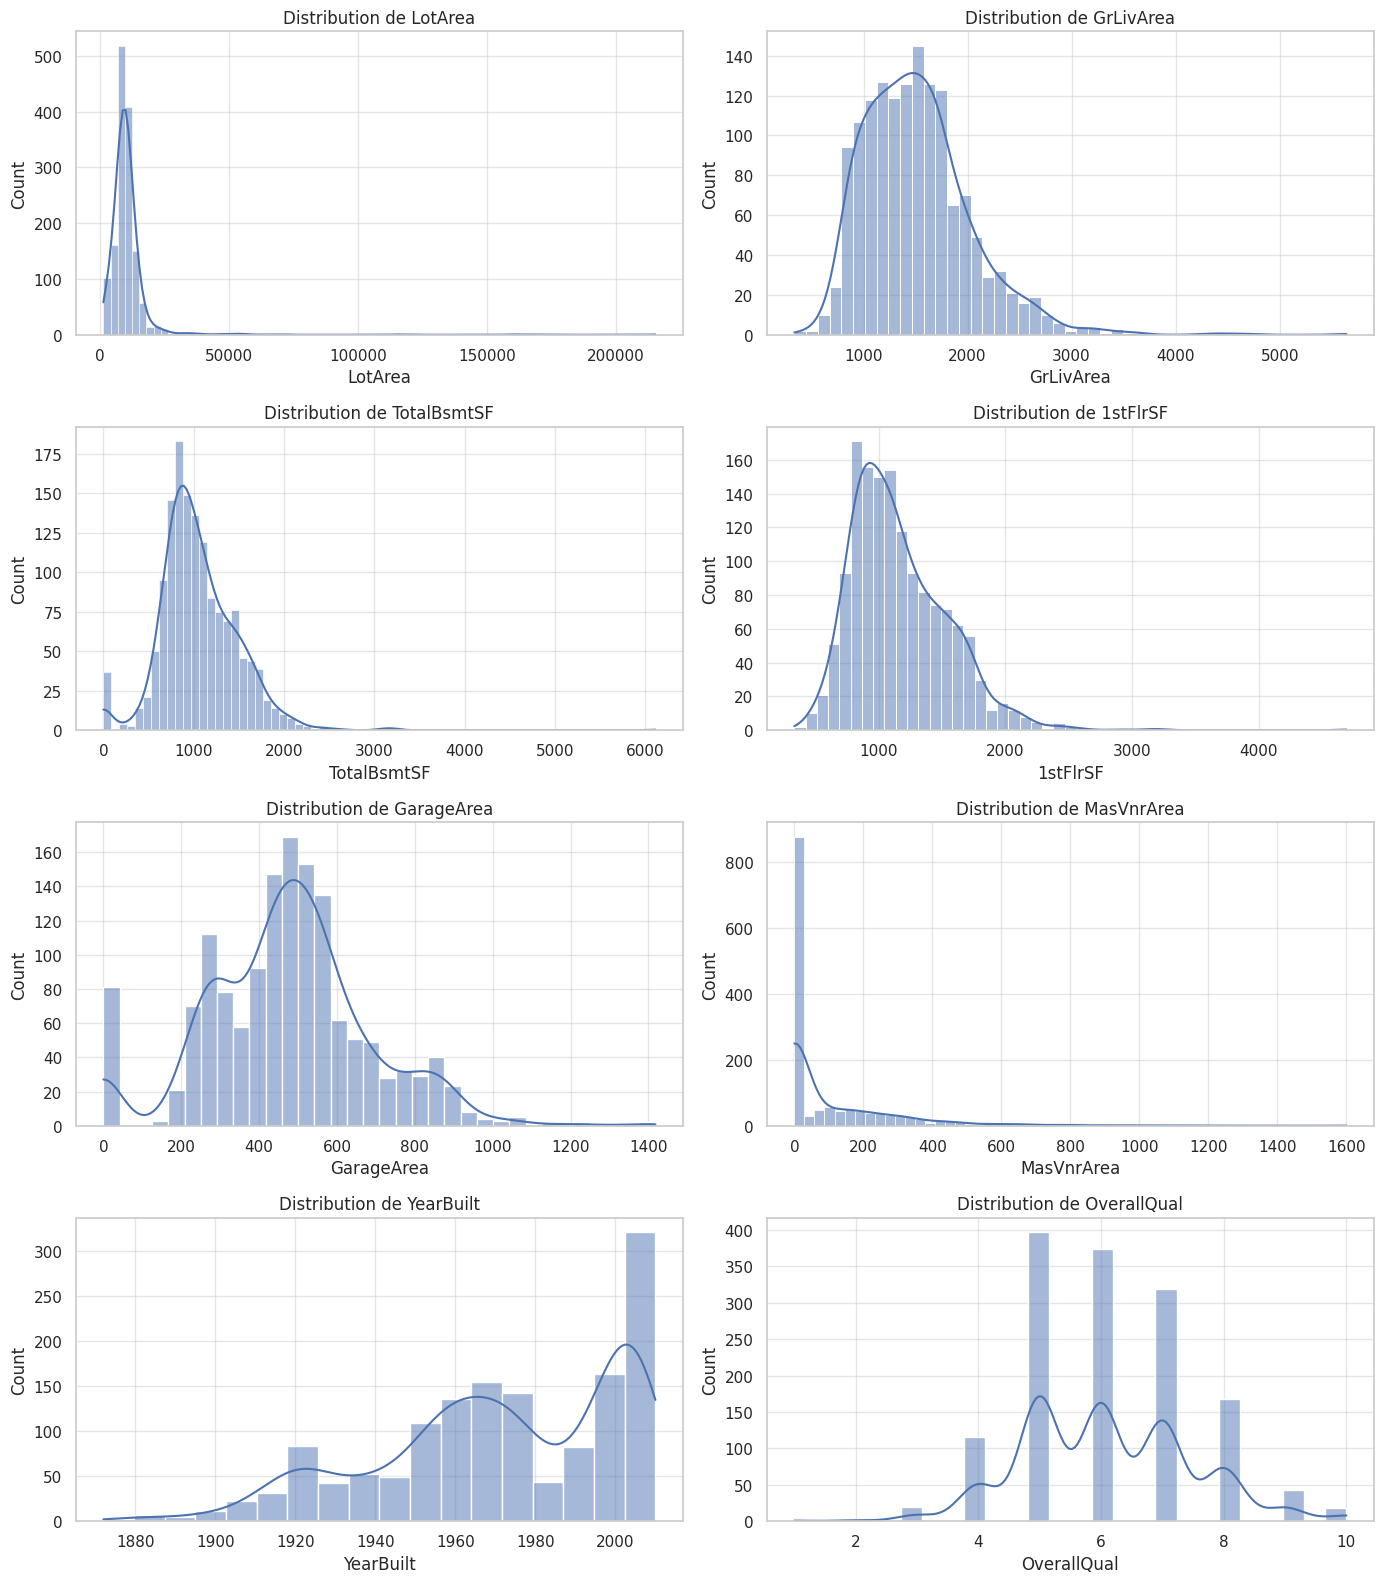

In [15]:
key_num_vars = [
    'LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF',
    'GarageArea', 'MasVnrArea', 'YearBuilt', 'OverallQual'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(key_num_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### 2.6.3 Détection visuelle des valeurs extrêmes

Les boxplots permettent de repérer rapidement les variables numériques présentant des valeurs très éloignées du cœur de la distribution. Cette étape aide à préparer l’analyse future des outliers.

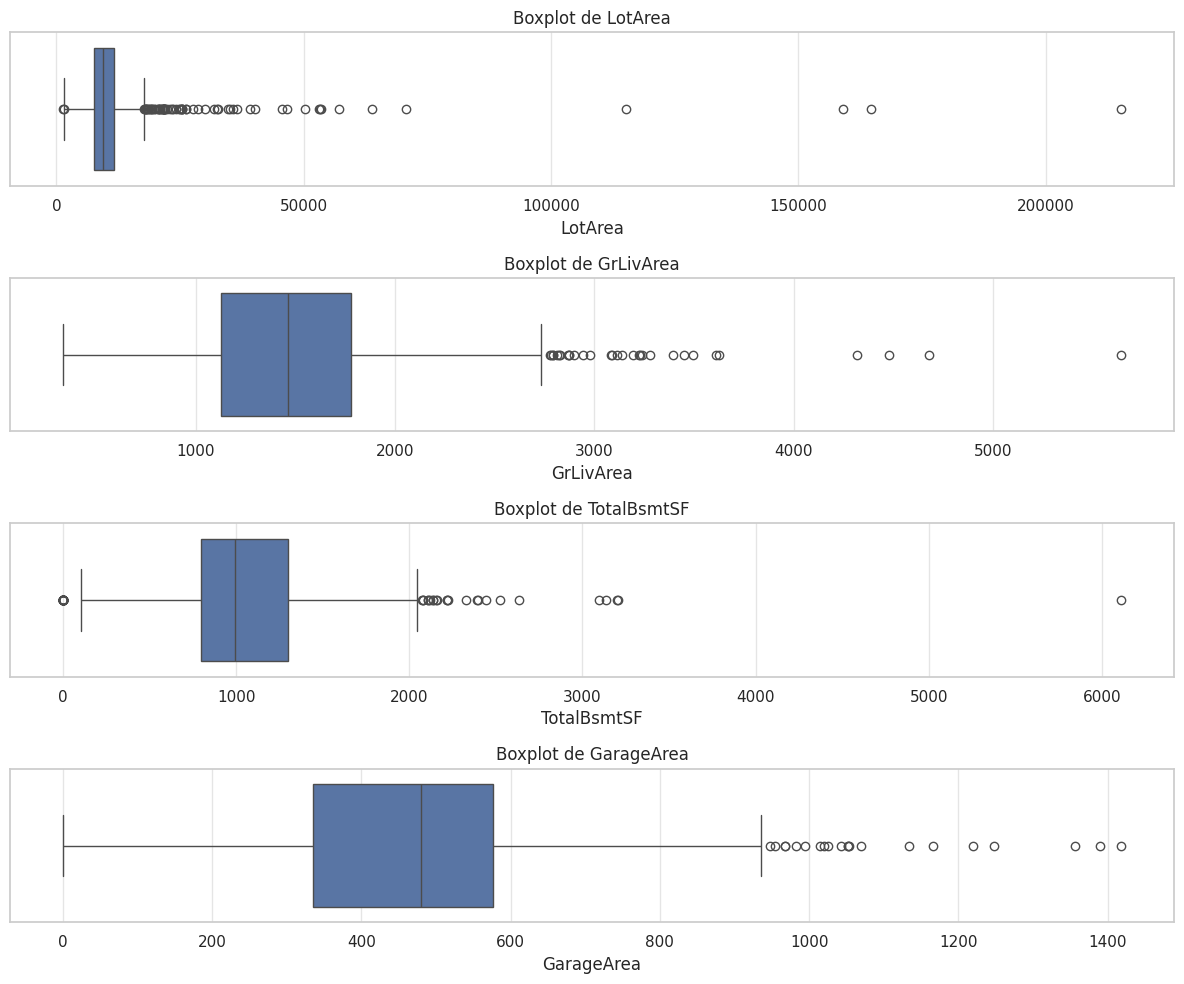

In [16]:
boxplot_vars = ['LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea']

fig, axes = plt.subplots(len(boxplot_vars), 1, figsize=(12, 10))

for i, col in enumerate(boxplot_vars):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### 2.6.4 Analyse des variables catégorielles

Nous poursuivons l’analyse univariée avec les variables catégorielles. L’objectif est d’identifier les modalités les plus fréquentes, les déséquilibres éventuels et la présence de catégories rares.

In [17]:
cat_features = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Nombre de variables catégorielles analysées : {len(cat_features)}")
print(cat_features)

Nombre de variables catégorielles analysées : 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


##### 2.6.4.1 Cardinalité des variables catégorielles

Nous examinons le nombre de modalités par variable catégorielle afin de distinguer les variables simples de celles qui présentent une forte diversité de catégories.

> *Question ouverte pour la préparation des données :* comment encoder les nominales à **forte cardinalité** (`Neighborhood` 25 modalités, `Exterior1st`/`Exterior2nd`, `MSSubClass`…) sans **exploser la dimensionnalité** (un OneHot naïf créerait des centaines de colonnes creuses) ? Ce point est tranché en Phase 3.

In [18]:
cat_cardinality = pd.DataFrame({
    'n_unique': df[cat_features].nunique(),
    'missing_count': df[cat_features].isnull().sum()
}).sort_values(by='n_unique', ascending=False)

display(cat_cardinality)

,n_unique,missing_count
Neighborhood,25,0
Exterior2nd,16,0
Exterior1st,15,0
Condition1,9,0
SaleType,9,0
HouseStyle,8,0
RoofMatl,8,0
Condition2,8,0
Functional,7,0
BsmtFinType2,6,38


##### 2.6.4.2 Fréquence des principales catégories

Nous représentons la fréquence de plusieurs variables catégorielles importantes afin de visualiser les modalités dominantes dans le jeu de données.

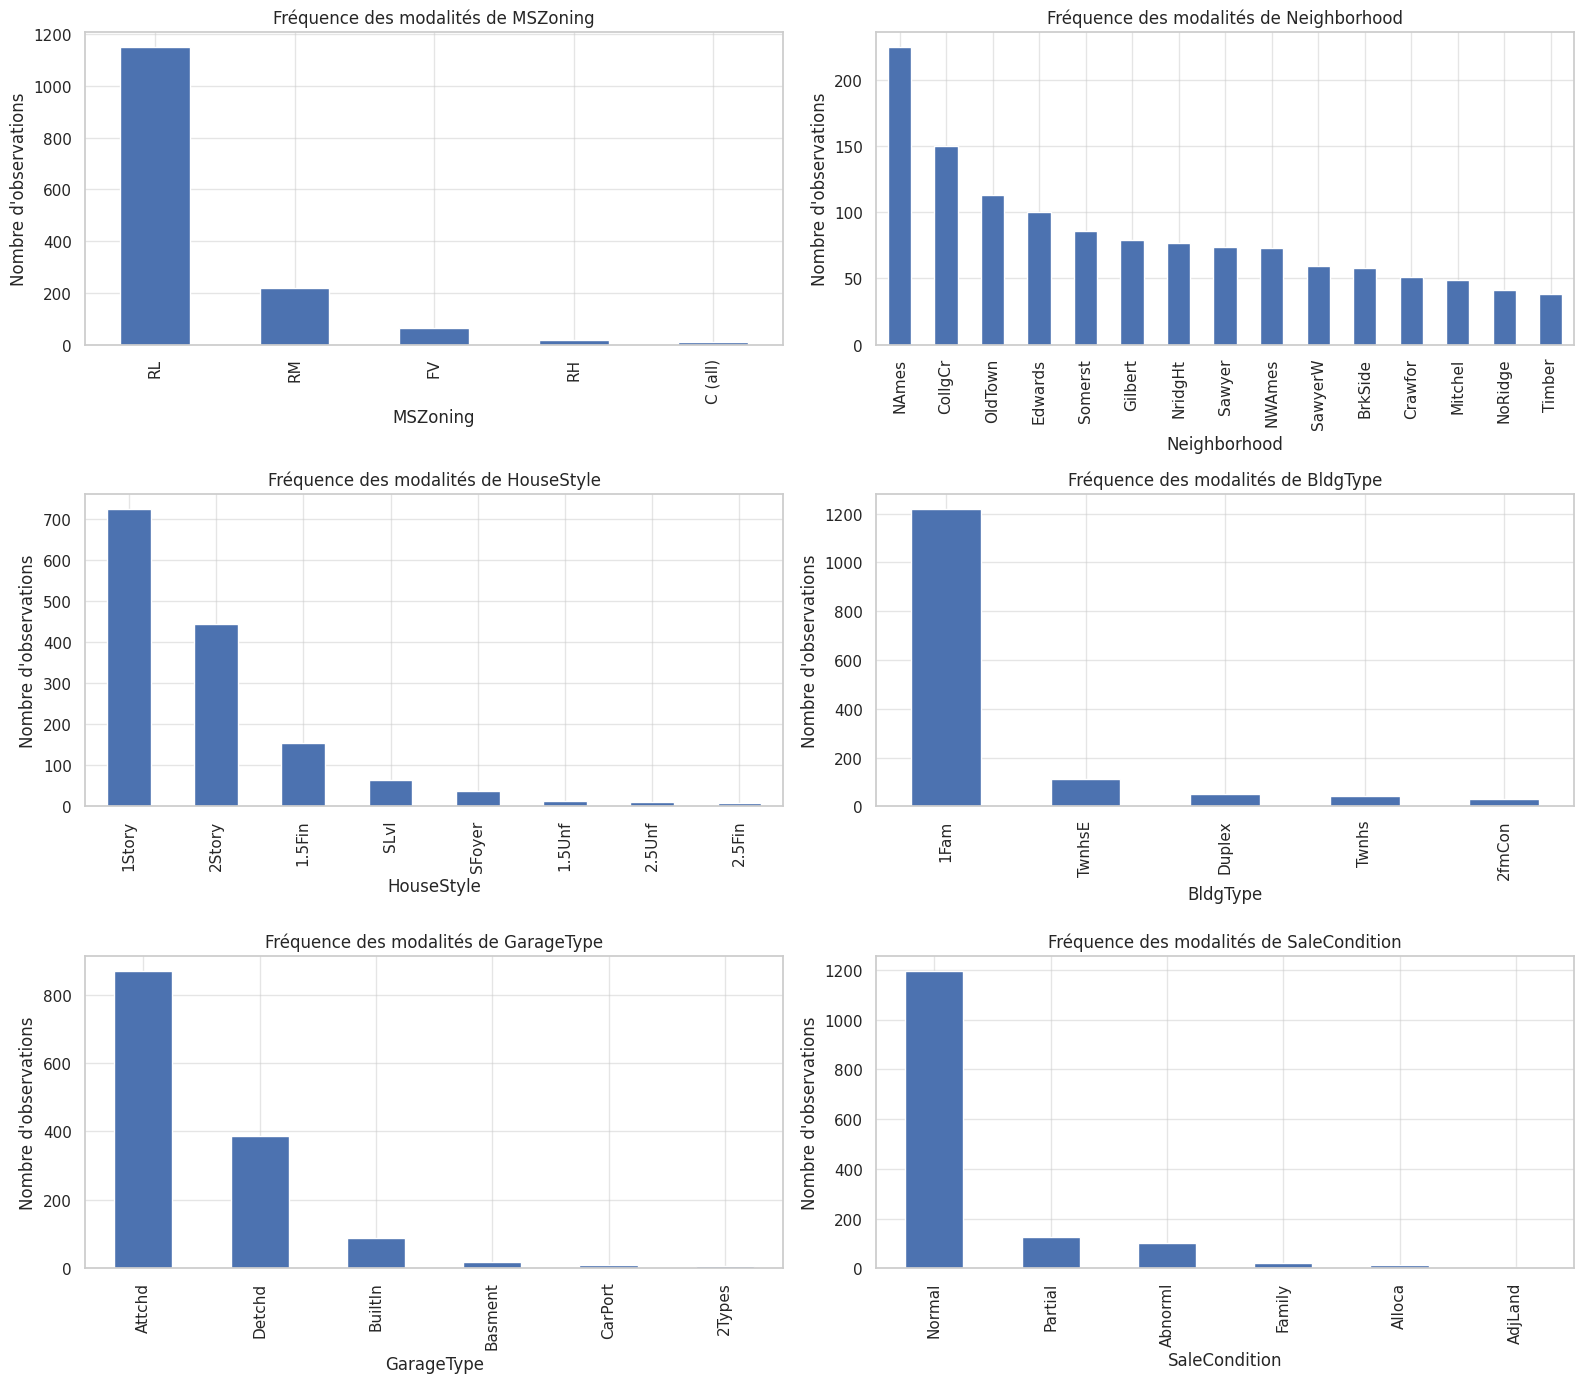

In [19]:
key_cat_vars = ['MSZoning', 'Neighborhood', 'HouseStyle', 'BldgType', 'GarageType', 'SaleCondition']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(key_cat_vars):
    df[col].value_counts().head(15).plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Fréquence des modalités de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

##### 2.6.4.3 Variables catégorielles ordinales

Certaines variables catégorielles représentent en réalité des niveaux ordonnés de qualité ou d’état. Cette particularité devra être prise en compte lors du prétraitement, car ces variables contiennent une information hiérarchique importante.

Ces variables suivent une échelle de notation standardisée, de la meilleure à la pire note :

`Ex` Excellent · `Gd` Good (Bon) · `TA` Typical/Average (Moyen) · `Fa` Fair (Passable) · `Po` Poor (Mauvais)

*(Une valeur manquante signifie ici que l'équipement est absent, pas de sous-sol, de garage, etc. cf. §2.5.2.)*

In [20]:
ordinal_candidates = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]

for col in ordinal_candidates:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False))


ExterQual
ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

ExterCond
ExterCond
TA    1282
Gd     146
Fa      28
Ex       3
Po       1
Name: count, dtype: int64

BsmtQual
BsmtQual
TA     649
Gd     618
Ex     121
NaN     37
Fa      35
Name: count, dtype: int64

BsmtCond
BsmtCond
TA     1311
Gd       65
Fa       45
NaN      37
Po        2
Name: count, dtype: int64

HeatingQC
HeatingQC
Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: count, dtype: int64

KitchenQual
KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

FireplaceQu
FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

GarageQual
GarageQual
TA     1311
NaN      81
Fa       48
Gd       14
Ex        3
Po        3
Name: count, dtype: int64

GarageCond
GarageCond
TA     1326
NaN      81
Fa       35
Gd        9
Po        7
Ex        2
Name: count, dtype: int64

PoolQC
PoolQC
NaN    1453
Gd        3
Ex        2
Fa      

#### 2.6.5 Synthèse de l’analyse univariée

L’analyse univariée met en évidence la diversité des profils présents dans le dataset. Les variables numériques présentent souvent des distributions asymétriques et parfois des valeurs extrêmes, tandis que les variables catégorielles révèlent des modalités dominantes ainsi que quelques catégories rares. Cette étape prépare l’analyse des liens entre les caractéristiques des biens et leur prix de vente.

### 2.7 Analyse bivariée avec la variable cible

Après avoir étudié les variables individuellement, nous analysons maintenant leur relation avec `SalePrice`. L’objectif est d’identifier les caractéristiques les plus liées au prix de vente et de repérer d’éventuelles tendances, corrélations ou observations atypiques.

In [21]:
# Corrélations des variables numériques avec SalePrice
num_for_corr = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice_log'], errors='ignore')
corr_with_target = num_for_corr.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

display(corr_with_target.to_frame(name='correlation_with_SalePrice'))

,correlation_with_SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


#### 2.7.1 Variables numériques les plus corrélées au prix

Nous examinons les variables numériques les plus corrélées positivement et négativement à `SalePrice` afin de repérer les facteurs les plus influents dans le jeu de données.

In [22]:
corr_no_target = corr_with_target.drop('SalePrice', errors='ignore')
top_pos_corr = corr_no_target.sort_values(ascending=False).head(10)
top_neg_corr = corr_no_target.sort_values(ascending=True).head(10)

print("Top corrélations positives avec SalePrice :")
display(top_pos_corr.to_frame())

print("Top corrélations les plus faibles / négatives avec SalePrice :")
display(top_neg_corr.to_frame())

Top corrélations positives avec SalePrice :


,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


Top corrélations les plus faibles / négatives avec SalePrice :


,SalePrice
KitchenAbvGr,-0.135907
EnclosedPorch,-0.128578
MSSubClass,-0.084284
OverallCond,-0.077856
YrSold,-0.028923
LowQualFinSF,-0.025606
Id,-0.021917
MiscVal,-0.021190
BsmtHalfBath,-0.016844
BsmtFinSF2,-0.011378


#### 2.7.2 Matrice de corrélation des variables les plus liées au prix

Nous représentons la matrice de corrélation des variables numériques les plus liées à `SalePrice`. Cette visualisation permet de voir à la fois leur lien avec la cible et les redondances éventuelles entre variables explicatives.

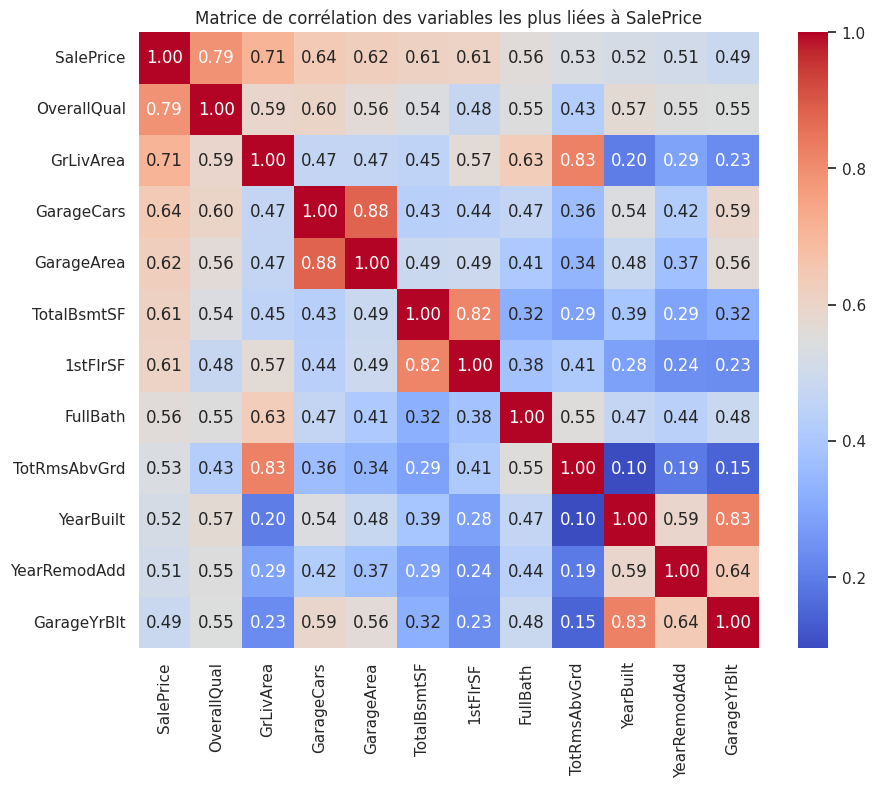

In [23]:
top_corr_vars = corr_with_target.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_vars].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation des variables les plus liées à SalePrice")
plt.show()

#### 2.7.3 Visualisation de quelques relations numériques avec le prix

Nous représentons plusieurs variables numériques importantes en fonction de `SalePrice` afin d’observer la forme de leur relation avec le prix de vente.

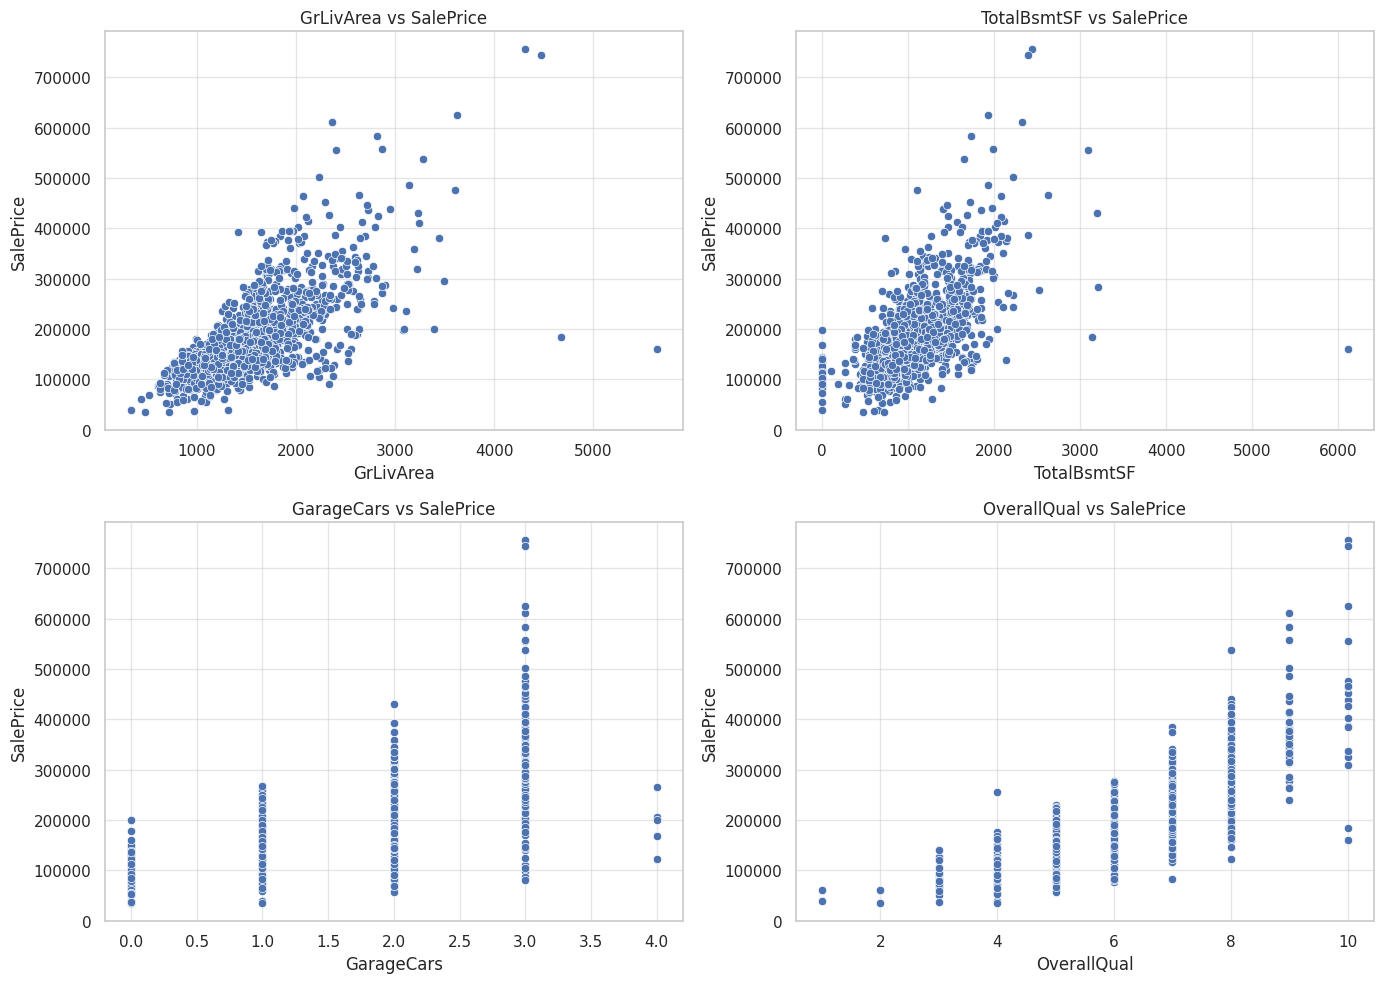

In [24]:
scatter_vars = ['GrLivArea', 'TotalBsmtSF', 'GarageCars', 'OverallQual']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_vars):
    sns.scatterplot(data=df, x=col, y='SalePrice', ax=axes[i])
    axes[i].set_title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()


#### 2.7.4 Analyse des variables catégorielles par rapport au prix

Nous étudions maintenant comment `SalePrice` varie selon certaines variables catégorielles. Les comparaisons de médianes permettent de repérer les catégories associées à des maisons plus chères ou moins chères.

##### 2.7.4.1 Comparaison visuelle des prix selon certaines catégories

Les boxplots permettent de comparer la distribution de `SalePrice` selon différentes catégories et d’observer les écarts de niveau de prix entre groupes.

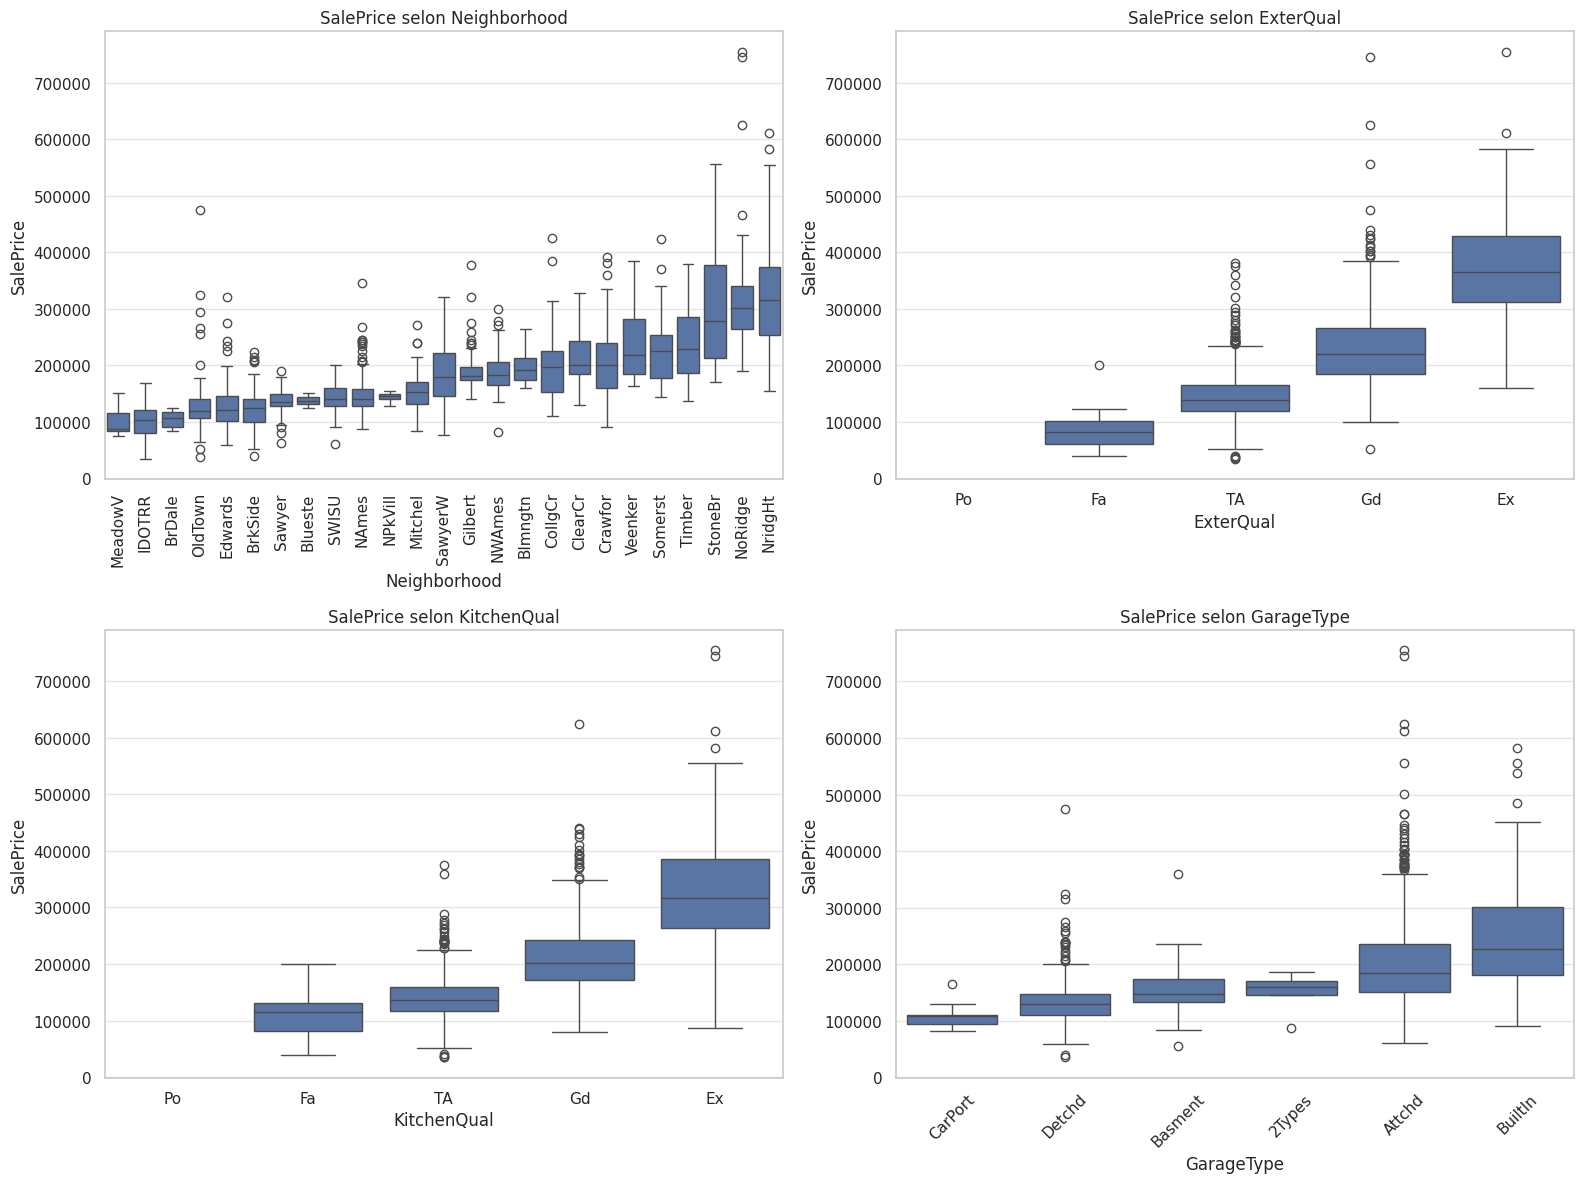

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Neighborhood
neigh_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=neigh_order, ax=axes[0, 0])
axes[0, 0].set_title("SalePrice selon Neighborhood")
axes[0, 0].tick_params(axis='x', rotation=90)

# ExterQual
qual_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
sns.boxplot(data=df, x='ExterQual', y='SalePrice', order=qual_order, ax=axes[0, 1])
axes[0, 1].set_title("SalePrice selon ExterQual")

# KitchenQual
sns.boxplot(data=df, x='KitchenQual', y='SalePrice', order=qual_order, ax=axes[1, 0])
axes[1, 0].set_title("SalePrice selon KitchenQual")

# GarageType
garage_order = df.groupby('GarageType')['SalePrice'].median().sort_values().index
sns.boxplot(data=df, x='GarageType', y='SalePrice', order=garage_order, ax=axes[1, 1])
axes[1, 1].set_title("SalePrice selon GarageType")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Quelles variables catégorielles portent réellement un signal sur le prix ?** On le teste par une **ANOVA à un facteur** : pour chaque variable, on compare la moyenne de `log(SalePrice)` entre ses modalités (H0 : toutes les modalités partagent la même moyenne). Une statistique F élevée et une p-value faible signalent une variable qui discrimine fortement le prix.

In [26]:
# ANOVA à un facteur : log(SalePrice) selon chaque catégorielle à fort impact
anova_cats = ['Neighborhood', 'KitchenQual', 'ExterQual', 'MSZoning', 'SaleCondition']
rows = []
for col in anova_cats:
    sub = df[[col, 'SalePrice_log']].dropna()
    groups = [g['SalePrice_log'].values for _, g in sub.groupby(col)]
    f_stat, p_val = stats.f_oneway(*groups)
    rows.append({'variable': col, 'n_modalités': df[col].nunique(), 'F': f_stat, 'p_value': p_val})
anova_df = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
display(anova_df)

,variable,n_modalités,F,p_value
0,Neighborhood,25,79.520424,4.043304e-243
1,ExterQual,4,415.303357,6.935425e-195
2,KitchenQual,4,393.320196,4.441486e-187
3,MSZoning,5,77.607843,1.021343e-59
4,SaleCondition,6,43.076712,1.689708e-41


**Lecture.** Toutes ces variables sont **hautement significatives** (p ≪ 0,05) : le quartier (`Neighborhood`) et les variables de qualité (`KitchenQual`, `ExterQual`) discriminent particulièrement le prix. Il faudra donc les **conserver** et les **encoder avec soin** en préparation, d'autant que `Neighborhood` est à forte cardinalité, ce qui pose la question de l'encodage sans explosion de la dimensionnalité (traité en Phase 3).

#### 2.7.5 Focus sur quelques variables particulièrement explicatives

Certaines variables apparaissent comme particulièrement liées au prix de vente. Nous les examinons plus en détail afin de mieux comprendre leur effet et leur intérêt pour la modélisation.

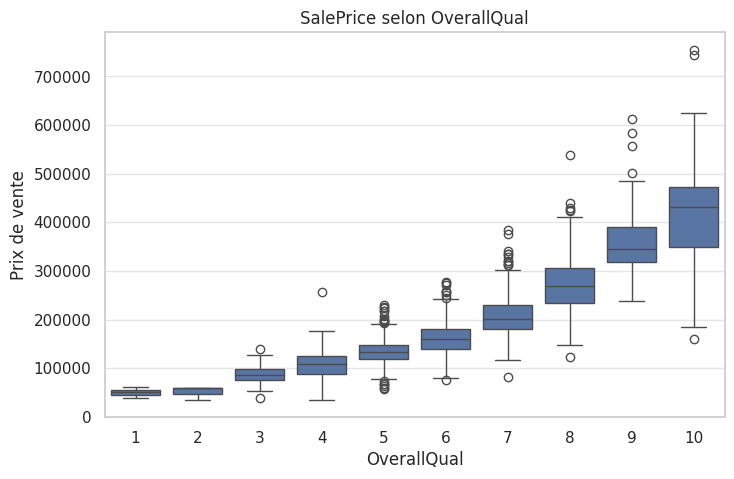

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='OverallQual', y='SalePrice')
plt.title("SalePrice selon OverallQual")
plt.xlabel("OverallQual")
plt.ylabel("Prix de vente")
plt.show()

#### 2.7.6 Synthèse de l’analyse bivariée

L’analyse bivariée met en évidence plusieurs facteurs fortement liés au prix de vente, en particulier la qualité globale du bien, la surface habitable, certaines caractéristiques du garage et la localisation. Elle révèle également des écarts marqués entre catégories ainsi que quelques observations atypiques, qui seront étudiées plus en détail dans la section consacrée aux corrélations et aux outliers.

### 2.8 Corrélations et redondances

Après avoir étudié les liens entre les variables et `SalePrice`, nous examinons ici les corrélations entre variables numériques explicatives. L’objectif est d’identifier d’éventuelles redondances, notamment entre variables de surface ou d’équipement.

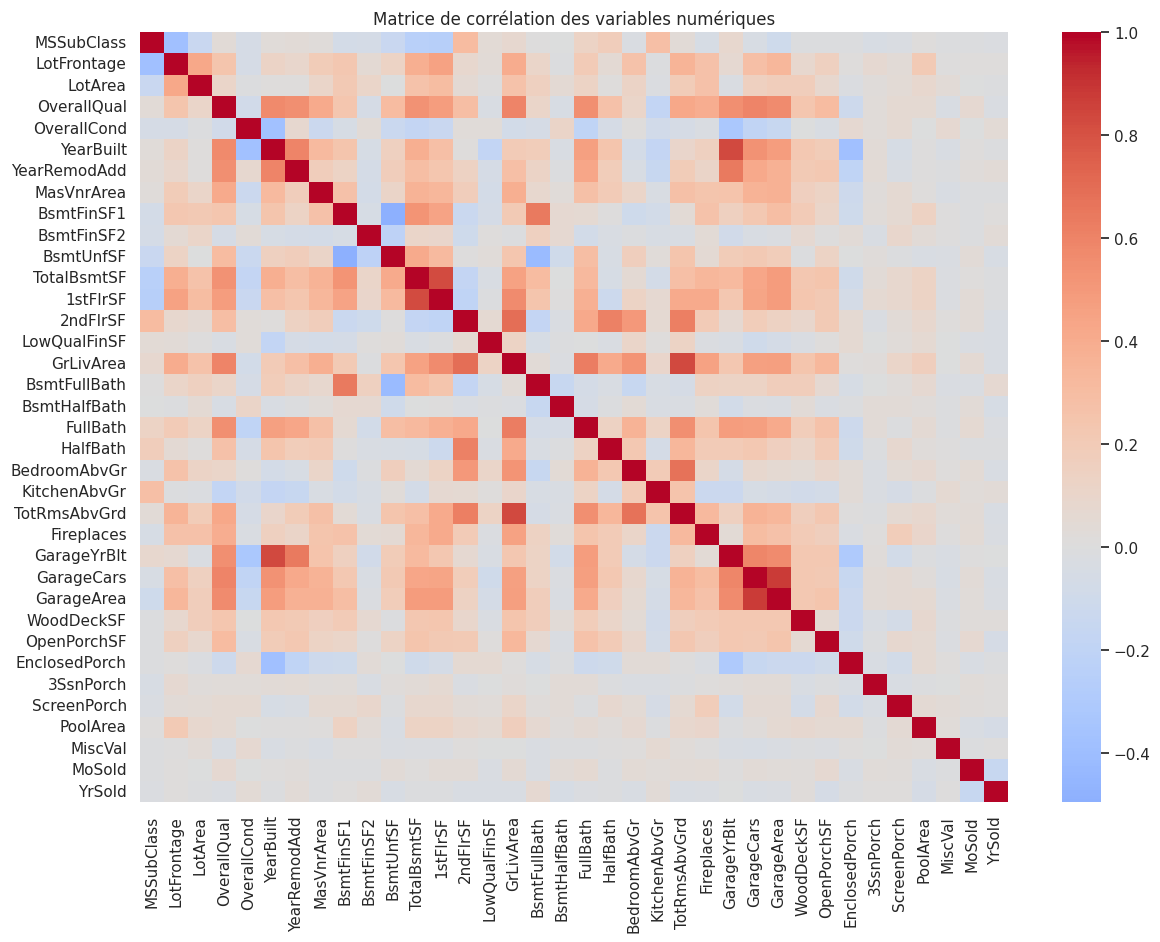

In [28]:
# Variables numériques hors cible
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features = [col for col in num_features if col not in ['Id', 'SalePrice', 'SalePrice_log']]

corr_matrix = df[num_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

#### 2.8.1 Paires de variables les plus corrélées

Nous listons les couples de variables numériques les plus corrélés afin de repérer les redondances potentielles dans les données.

In [29]:
# Extraction des corrélations fortes entre variables explicatives
corr_pairs = corr_matrix.abs().unstack().reset_index()
corr_pairs.columns = ['var1', 'var2', 'corr']

# Suppression des doublons et des auto-corrélations
corr_pairs = corr_pairs[corr_pairs['var1'] != corr_pairs['var2']]
corr_pairs['pair'] = corr_pairs.apply(lambda x: tuple(sorted([x['var1'], x['var2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset='pair').drop(columns='pair')

# Tri décroissant
top_corr_pairs = corr_pairs.sort_values(by='corr', ascending=False)

display(top_corr_pairs.head(15))

,var1,var2,corr
926,GarageCars,GarageArea,0.882475
204,YearBuilt,GarageYrBlt,0.825667
562,GrLivArea,TotRmsAbvGrd,0.825489
408,TotalBsmtSF,1stFlrSF,0.819530
483,2ndFlrSF,GrLivArea,0.687501
742,BedroomAbvGr,TotRmsAbvGrd,0.676620
304,BsmtFinSF1,BsmtFullBath,0.649212
240,YearRemodAdd,GarageYrBlt,0.642277
558,GrLivArea,FullBath,0.630012
490,2ndFlrSF,TotRmsAbvGrd,0.616423


#### 2.8.2 Focus sur quelques variables très corrélées

Nous visualisons quelques relations fortes entre variables pour mieux comprendre les redondances observées dans la matrice de corrélation.

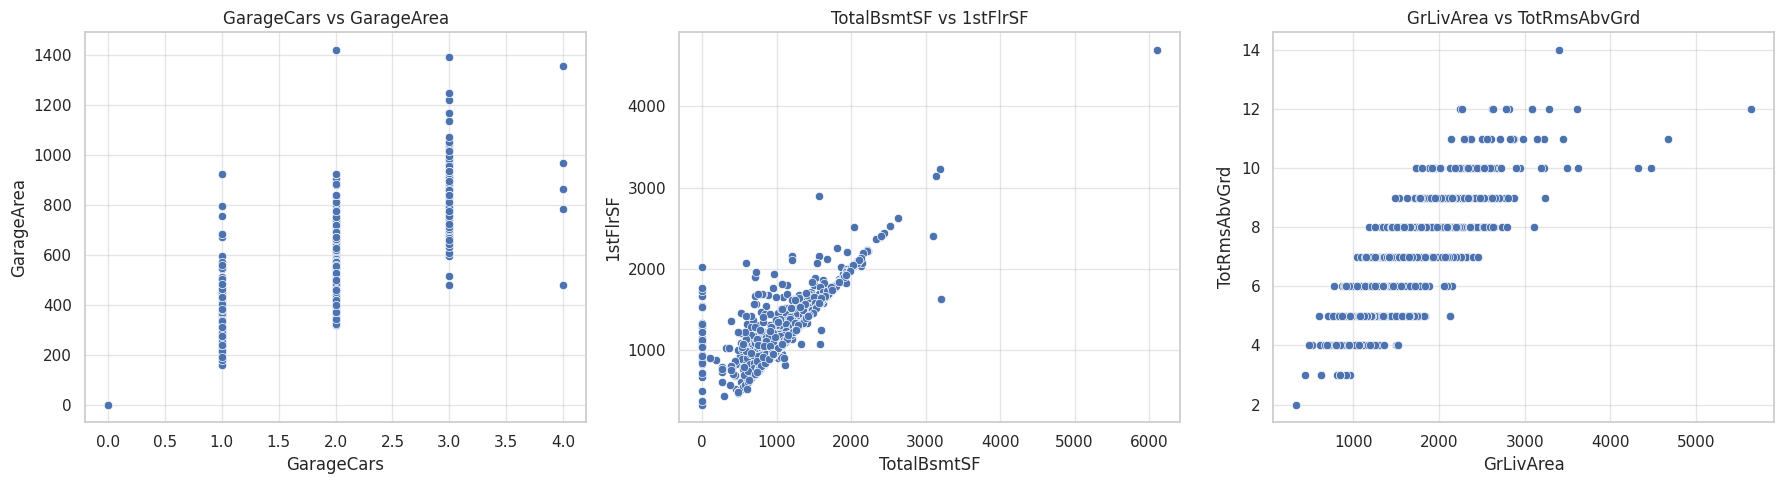

In [30]:
selected_pairs = [
    ('GarageCars', 'GarageArea'),
    ('TotalBsmtSF', '1stFlrSF'),
    ('GrLivArea', 'TotRmsAbvGrd')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (x_col, y_col) in enumerate(selected_pairs):
    sns.scatterplot(data=df, x=x_col, y=y_col, ax=axes[i])
    axes[i].set_title(f"{x_col} vs {y_col}")

plt.tight_layout()
plt.show()

#### 2.8.3 Synthèse sur les corrélations

L’analyse met en évidence plusieurs redondances entre variables explicatives, en particulier autour des surfaces, du garage et de certaines mesures structurelles du bien. Ces liens n’empêchent pas leur utilisation, mais ils devront être gardés à l’esprit lors de l’interprétation des modèles.

### 2.9 Outliers et observations atypiques

Nous terminons l’EDA par l’identification de quelques observations atypiques. L’objectif n’est pas de supprimer automatiquement ces points, mais de repérer les cas qui s’écartent fortement des tendances générales et qui pourraient influencer la modélisation.

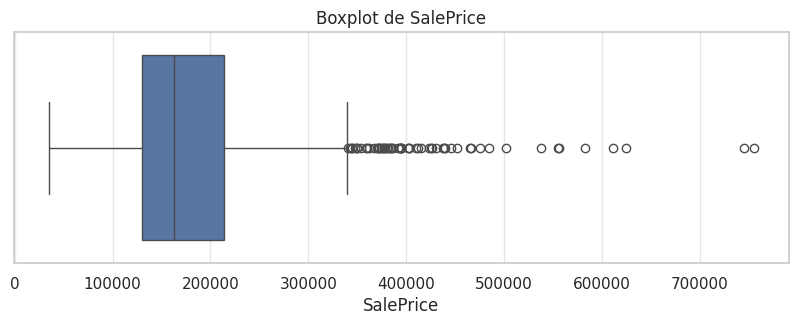

Nombre d'outliers détectés sur SalePrice (règle IQR) : 61


,Id,SalePrice
691,692,755000
1182,1183,745000
1169,1170,625000
898,899,611657
803,804,582933
1046,1047,556581
440,441,555000
769,770,538000
178,179,501837
798,799,485000


In [31]:
# Boxplot de la cible
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['SalePrice'])
plt.title("Boxplot de SalePrice")
plt.xlabel("SalePrice")
plt.show()

# Seuil IQR pour repérage simple
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

saleprice_outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]

print(f"Nombre d'outliers détectés sur SalePrice (règle IQR) : {saleprice_outliers.shape[0]}")
display(saleprice_outliers[['Id', 'SalePrice']].sort_values(by='SalePrice', ascending=False).head(10))

#### 2.9.1 Observation des atypies sur les variables explicatives majeures

Nous examinons ensuite quelques variables importantes pour repérer des observations très éloignées de la distribution centrale, notamment sur les surfaces.

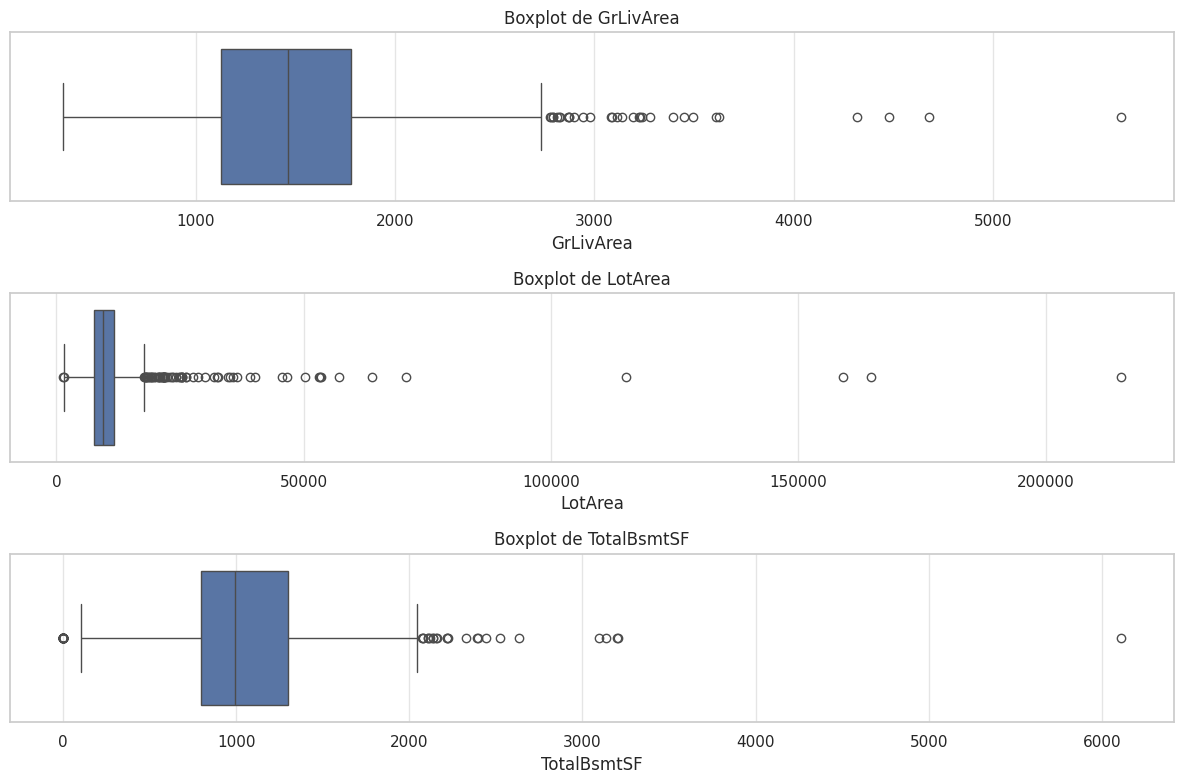

In [32]:
outlier_vars = ['GrLivArea', 'LotArea', 'TotalBsmtSF']

fig, axes = plt.subplots(len(outlier_vars), 1, figsize=(12, 8))

for i, col in enumerate(outlier_vars):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### 2.9.2 Focus sur les observations atypiques de `GrLivArea`

La relation entre `GrLivArea` et `SalePrice` permet d’identifier visuellement certaines maisons très grandes dont le prix reste relativement faible. Ces cas sont particulièrement importants pour la suite.

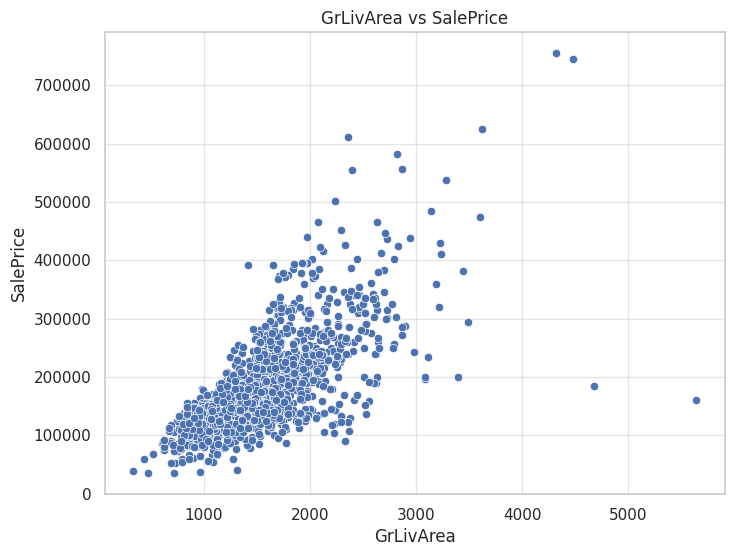

,Id,GrLivArea,SalePrice,OverallQual,Neighborhood
1298,1299,5642,160000,10,Edwards
523,524,4676,184750,10,Edwards
1182,1183,4476,745000,10,NoRidge
691,692,4316,755000,10,NoRidge


In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

# Affichage des très grandes surfaces
large_houses = df[df['GrLivArea'] > 4000][['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']]
display(large_houses.sort_values(by='GrLivArea', ascending=False))

#### 2.9.3 Synthèse et Gestion des Outliers : Le piège des maisons de luxe

Lors de notre analyse des valeurs extrêmes, nous avons identifié des propriétés dans le quartier `NoRidge` avec des prix avoisinant les 750 000 $.
**Cependant, un prix élevé ne signifie pas nécessairement qu'il s'agit d'une anomalie statistique (outlier).** Ces maisons possèdent une surface habitable immense et une qualité globale (`OverallQual`) maximale de 10. Leur prix est donc parfaitement cohérent avec la tendance du marché : ce sont de simples maisons de luxe. Les supprimer empêcherait notre modèle de savoir évaluer des biens haut de gamme.

**Où sont les vrais outliers ?**
Selon les recommandations de Dean De Cock (le créateur du dataset d'Ames), les véritables anomalies qui menacent de fausser nos futurs modèles linéaires (points de levier) sont les propriétés présentant une surface habitable anormalement grande (plus de 4000 sq ft) mais vendues à un prix dérisoire (moins de 300 000 $). Ces ventes s'expliquent souvent par des contextes non représentatifs du marché (ventes familiales, biens agricoles partiels, etc.).

Le graphique ci-dessous illustre parfaitement cette dynamique :

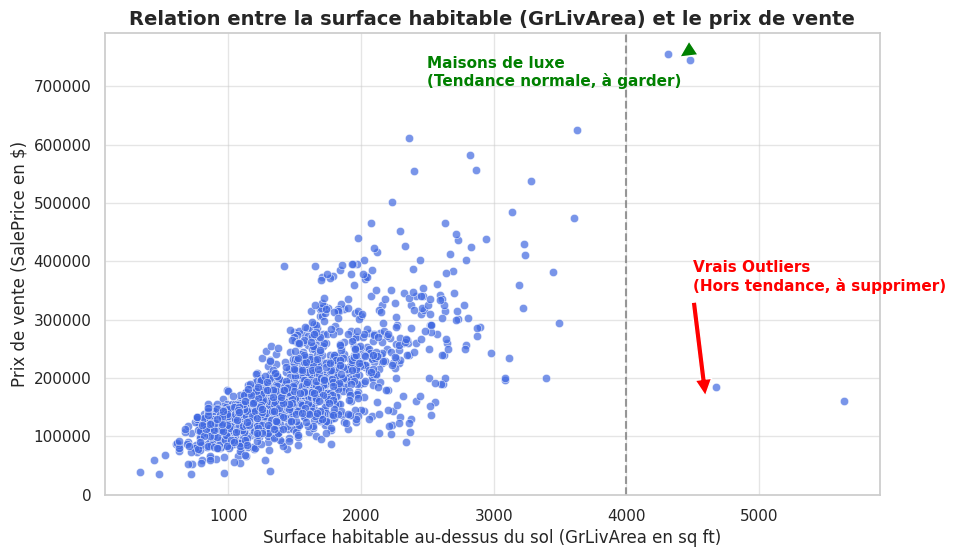

In [34]:
# Création du graphique de dispersion
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], alpha=0.7, color='royalblue')

# Ajout d'une ligne de démarcation pour les 4000 sq ft
plt.axvline(x=4000, color='gray', linestyle='--', alpha=0.8)

# Annotation pour les maisons de luxe (Normales)
plt.annotate('Maisons de luxe\n(Tendance normale, à garder)',
             xy=(4400, 750000), xytext=(2500, 700000),
             arrowprops=dict(facecolor='green', shrink=0.05),
             fontsize=11, color='green', fontweight='bold')

# Annotation pour les vrais outliers (Anomalies)
plt.annotate('Vrais Outliers\n(Hors tendance, à supprimer)',
             xy=(4600, 160000), xytext=(4500, 350000),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=11, color='red', fontweight='bold')

plt.title("Relation entre la surface habitable (GrLivArea) et le prix de vente", fontsize=14, fontweight='bold')
plt.xlabel("Surface habitable au-dessus du sol (GrLivArea en sq ft)", fontsize=12)
plt.ylabel("Prix de vente (SalePrice en $)", fontsize=12)

plt.show()

**Décision pour le nettoyage (Phase 3) :**
Pour protéger nos algorithmes, nous devrons impérativement filtrer et supprimer du jeu d'entraînement les observations où `GrLivArea > 4000` ET `SalePrice < 300000`. Cette action sera la toute première étape de notre prochain notebook.

### 2.10 Analyse des Corrélations et Multicolinéarité

Maintenant que nous comprenons nos variables, il est crucial de vérifier si certaines d'entre elles font "doublon". C'est ce qu'on appelle la **multicolinéarité**. Si deux variables donnent exactement la même information à notre futur modèle de régression, cela risque de perturber ses coefficients et de fausser ses prédictions.

Nous allons cibler les variables indépendantes qui ont une corrélation supérieure à 0.80 entre elles.

In [35]:
# Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

# Extraire les paires avec une très forte corrélation (> 0.80)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.80:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((colname_i, colname_j, corr_value))

print("Paires de variables fortement corrélées (Multicolinéarité suspectée) :")
print("-" * 65)
for pair in high_corr_pairs:
    print(f"- {pair[0]} et {pair[1]} : {pair[2]:.2f}")

Paires de variables fortement corrélées (Multicolinéarité suspectée) :
-----------------------------------------------------------------
- 1stFlrSF et TotalBsmtSF : 0.82
- TotRmsAbvGrd et GrLivArea : 0.83
- GarageYrBlt et YearBuilt : 0.83
- GarageArea et GarageCars : 0.88
- SalePrice_log et OverallQual : 0.82
- SalePrice_log et SalePrice : 0.95


### 2.11 Conclusion de l'EDA et Plan d'Action pour le Nettoyage (Phase 3)

Notre analyse exploratoire (EDA) est terminée. Avant de pouvoir entraîner notre modèle IA pour **Inved Corp**, nous devons préparer les données. Voici le cahier des charges exact que nous appliquerons au début du prochain notebook :

1. **Suppression des vrais outliers :** Nous filtrerons les maisons de plus de 4000 sq ft vendues à moins de 300 000 $ (les fameuses anomalies d'Edwards) pour protéger nos modèles linéaires.
2. **Gestion de la multicolinéarité :** Pour alléger le modèle et éviter les conflits, nous supprimerons une variable sur deux dans les paires fortement corrélées (ex: nous garderons `GarageCars` et supprimerons `GarageArea`).
3. **Traitement des valeurs manquantes :** L'analyse des données montre que les forts taux de NaN (ex: PoolQC, MiscFeature, Alley, Fence) cachent en réalité une information métier cruciale : l'absence de l'équipement. Elles seront donc conservées et valorisées par la constante "None". Les variables numériques manquantes seront imputées par leur médiane (et par la médiane spécifique du quartier pour LotFrontage). Seule la variable Utilities, étant quasi-constante (variance nulle), sera purement supprimée.
4. **Transformation logarithmique :** Notre métrique cible étant le **RMSLE**, nous devrons appliquer une transformation `log1p` sur notre variable cible `SalePrice`.
5. **Encodage des catégorielles à forte cardinalité :** des variables comme `Neighborhood` (25 modalités), `Exterior1st`/`Exterior2nd` ou `MSSubClass` portent un fort signal (cf. ANOVA ci-dessus) mais un OneHot naïf exploserait la dimensionnalité ; nous adopterons une stratégie d'encodage plus fine (ordinal pour les échelles de qualité, encodage par la cible pour les nominales à forte cardinalité).

Direction le Notebook `2_data_prep.ipynb` pour l'implémentation !